## Preparing Data for CNN

In [1]:
from importlib.metadata import files

import numpy as np
import h5py
import tensorflow as tf
import sklearn
import matplotlib
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


print("NumPy:", np.__version__)
print("h5py:", h5py.__version__)
print("TensorFlow:", tf.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib backend:", matplotlib.get_backend())

NumPy: 2.5.1
h5py: 3.14.0
TensorFlow: 2.21.0
Scikit-learn: 1.9.0
Matplotlib: 3.11.1
Seaborn: 0.13.2
Pandas: 3.0.5
Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Load the dataset
filename = "./sample_data/GOLD_XYZ_OSC.0001_1024.hdf5"

f = h5py.File(filename, "r")

X = f["X"]
Y = f["Y"]
Z = f["Z"]

print("X:", X.shape)
print("Y:", Y.shape)
print("Z:", Z.shape)

In [ ]:
labels = np.argmax(Y[:], axis=1)
snrs = Z[:].reshape(-1)

print("Labels:", labels.shape)
print("SNRs:", snrs.shape)

In [ ]:
import numpy as np

In [ ]:
#selected class for training and testing

selected_classes = [
    "OOK",
    "BPSK",
    "QPSK",
    "AM-DSB-WC",
    "AM-DSB-SC",
    "FM"
]

## Converting original labels to new lables

In [ ]:
class_to_new_lables={modulation: i for i,modulation in enumerate(selected_classes)}

In [ ]:
print("Selected classes:", selected_classes)

In [ ]:
print(class_to_new_lables)

## Finding the original class indices

In [ ]:
import json

with open("./sample_data/classes-fixed.json", "r") as f:
    classes = json.load(f)

In [ ]:
selected_class_indices = [
    classes.index(modulation)
    for modulation in selected_classes
]

print(selected_class_indices)

## Selecting the samples

In [ ]:
samples_per_class_snr = 1000

In [ ]:
selected_snrs = [-10, -4, 0, 4, 10, 16, 20]

that gives: 6*7*1000=42,000 samples

In [ ]:
# Load a subset of the CNN dataset. 

def load_cnn_subset(
    X,
    labels,
    snrs,
    classes,
    selected_classes,
    selected_snrs,
    samples_per_class_snr=1000,
    seed=42
):
    
    rng = np.random.default_rng(seed)

    X_data = []
    y_data = []
    snr_data = []

    for new_label, modulation in enumerate(selected_classes):

        original_label = classes.index(modulation)

        for snr in selected_snrs:

            indices = np.where(
                (labels == original_label) &
                (snrs == snr)
            )[0]

            if len(indices) < samples_per_class_snr:
                raise ValueError(
                    f"Not enough samples for "
                    f"{modulation} at {snr} dB"
                )

            # Randomly select indices
            selected_indices = rng.choice(
                indices,
                size=samples_per_class_snr,
                replace=False
            )

            # h5py requires increasing indices
            selected_indices.sort()

            # Load only the selected IQ samples
            X_data.append(X[selected_indices])

            y_data.extend(
                [new_label] * samples_per_class_snr
            )

            snr_data.extend(
                [snr] * samples_per_class_snr
            )

    X_data = np.concatenate(X_data, axis=0)
    y_data = np.array(y_data)
    snr_data = np.array(snr_data)

    return X_data, y_data, snr_data

In [ ]:
X_cnn, y_cnn, snr_cnn = load_cnn_subset(
    X=X,
    labels=labels,
    snrs=snrs,
    classes=classes,
    selected_classes=selected_classes,
    selected_snrs=selected_snrs,
    samples_per_class_snr=1000
)

In [ ]:
print("X shape:", X_cnn.shape)
print("y shape:", y_cnn.shape)
print("SNR shape:", snr_cnn.shape)

In [ ]:
print("Available SNR values:")
print(np.unique(snrs))

In [ ]:
print("Selected SNRs:", selected_snrs)
print("Number of SNRs:", len(selected_snrs))

In [ ]:
for i, modulation in enumerate(selected_classes):
    print(
        modulation,
        np.sum(y_cnn == i)
    )

In [ ]:
print("X:", X_cnn.shape)
print("y:", y_cnn.shape)
print("SNR:", snr_cnn.shape)

print("\nFirst IQ sample:")
print(X_cnn[0][:5])

print("\nFirst label:")
print(y_cnn[0])

print("\nFirst SNR:")
print(snr_cnn[0])

In [ ]:
print("\nClass distribution:")
for i, modulation in enumerate(selected_classes):
    print(f"{modulation:12s}: {np.sum(y_cnn == i)}")

print("\nSNR distribution:")
for snr in selected_snrs:
    print(f"{snr:>4} dB: {np.sum(snr_cnn == snr)}")

## Train / Validation / Test Split


In [ ]:
# Create a stratification key for train-test split

stratify_key = np.array([
    f"{label}_{snr}"
    for label, snr in zip(y_cnn, snr_cnn)
])

In [ ]:
stratify_key

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X_cnn,
    y_cnn,
    snr_cnn,
    test_size=0.30,
    random_state=42,
    stratify=stratify_key
)

In [ ]:
# Split the temporary set into validation and test

temp_stratify_key = np.array([
    f"{label}_{snr}"
    for label, snr in zip(y_temp, snr_temp)
])

temp_stratify_key

In [ ]:
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp,
    y_temp,
    snr_temp,
    test_size=0.50,
    random_state=42,
    stratify=temp_stratify_key
)

In [ ]:
# Print the shapes of the splits training, validation, and testing sets
print("Training:")
print("X:", X_train.shape)
print("y:", y_train.shape)
print("SNR:", snr_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("y:", y_val.shape)
print("SNR:", snr_val.shape)

print("\nTesting:")
print("X:", X_test.shape)
print("y:", y_test.shape)
print("SNR:", snr_test.shape)

In [ ]:
#Verify class distribution
from collections import Counter

print("Training class distribution:")
for label, count in sorted(Counter(y_train).items()):
    print(f"{selected_classes[label]:12s}: {count}")

print("\nValidation class distribution:")
for label, count in sorted(Counter(y_val).items()):
    print(f"{selected_classes[label]:12s}: {count}")

print("\nTest class distribution:")
for label, count in sorted(Counter(y_test).items()):
    print(f"{selected_classes[label]:12s}: {count}")

In [ ]:
# Verify SNR distribution
print("Training SNR distribution:")
for snr, count in sorted(Counter(snr_train).items()):
    print(f"{snr:>4} dB: {count}")

print("\nValidation SNR distribution:")
for snr, count in sorted(Counter(snr_val).items()):
    print(f"{snr:>4} dB: {count}")

print("\nTest SNR distribution:")
for snr, count in sorted(Counter(snr_test).items()):
    print(f"{snr:>4} dB: {count}")

In [ ]:
#Inspect the IQ data before normalizing
print("X_train dtype:", X_train.dtype)

print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("Mean:", X_train.mean())
print("Standard deviation:", X_train.std())

In [ ]:
# instecting I and Q data after normalization
print("I mean:", X_train[:, :, 0].mean())
print("I std:", X_train[:, :, 0].std())

print("Q mean:", X_train[:, :, 1].mean())
print("Q std:", X_train[:, :, 1].std())

In [ ]:
sample = X_train[0]

print("Sample shape:", sample.shape)
print("First 10 I values:", sample[:10, 0])
print("First 10 Q values:", sample[:10, 1])

In [ ]:
# ==========================================
# 8. Input Normalization
# ==========================================

# Calculate statistics ONLY from training data
train_mean = X_train.mean()
train_std = X_train.std()

print("Mean:", train_mean)
print("Std:", train_std)

In [ ]:
#normalize the training, validation, and test sets using the training statistics
X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

In [ ]:
print("Normalized training mean:", X_train_norm.mean())
print("Normalized training std:", X_train_norm.std())

print("Normalized validation mean:", X_val_norm.mean())
print("Normalized validation std:", X_val_norm.std())

print("Normalized test mean:", X_test_norm.mean())
print("Normalized test std:", X_test_norm.std())

In [ ]:
# Reshape the data for CNN input
# new shape: (num_samples, num_time_steps, num_features, 1)

X_train_cnn = np.expand_dims(X_train_norm, axis=-1)
X_val_cnn   = np.expand_dims(X_val_norm, axis=-1)
X_test_cnn  = np.expand_dims(X_test_norm, axis=-1)

In [ ]:
print("X_train CNN shape:", X_train_cnn.shape)
print("X_val CNN shape:", X_val_cnn.shape)
print("X_test CNN shape:", X_test_cnn.shape)

## CNN Model Development

Input
(1024, 2, 1)
      ↓
Conv2D 32
      ↓
BatchNorm
      ↓
ReLU
      ↓
MaxPool (2,1)
      ↓
Conv2D 64
      ↓
BatchNorm
      ↓
ReLU
      ↓
MaxPool (2,1)
      ↓
Conv2D 128
      ↓
BatchNorm
      ↓
ReLU
      ↓
MaxPool (2,1)
      ↓
Global Average Pooling
      ↓
Dense 128
      ↓
Dropout 0.5
      ↓
Dense 6
      ↓
Softmax

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequential([
    
    # Input
    layers.Input(shape=(1024, 2, 1)),

    # Convolution Block 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 2),
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 1)),

    # Convolution Block 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 1),
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 1)),

    # Convolution Block 3
    layers.Conv2D(
        filters=128,
        kernel_size=(3, 1),
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 1)),

    # Classification Head
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 6 modulation classes
    layers.Dense(6, activation="softmax")
])

In [ ]:
model.summary()

In [ ]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected. Training should be performed on the GPU machine.")

In [ ]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

print("Model directory:", MODEL_DIR.resolve())

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/best_baseline_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="min",
    verbose=1
)

In [ ]:
#adding callbacks for early stopping and learning rate reduction
callbacks = [
    checkpoint,

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# saving the model
model.save(
    "models/final_baseline_cnn.keras"
)

print("Final model saved.")

In [ ]:
# saving training history
import json
with open("results/training_history.pkl", "wb") as f:
     json.dump(
        history.history,
        f,
        indent=4
    )

print("Training history saved.")

In [ ]:
# saving the training history to a CSV file
history_df = pd.DataFrame(history.history)

history_df.index.name = "epoch"

history_df.to_csv(
    "results/metrics/training_history.csv"
)

print(history_df)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)


## Training Curves

In [ ]:
# ==========================================
# Training and Validation Curves
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "results/metrics/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "results/metrics/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#loading the best model for evaluation
best_model = tf.keras.models.load_model(
    "models/best_baseline_cnn.keras"
)

print("Best model loaded successfully.")

In [ ]:
# evaluating on the test set
test_loss, test_accuracy = best_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

In [ ]:
#saving the evaluation metrics to a text file
test_results = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_percent": float(test_accuracy * 100)
}

with open(
    "results/metrics/test_results.json",
    "w"
) as f:

    json.dump(
        test_results,
        f,
        indent=4
    )

In [ ]:
#geneerate predictions on the test set
y_prob = model.predict(
    X_test_cnn,
    batch_size=128,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

In [ ]:
#save the predictions to a CSV file along with the true labels and SNR values

prediction_results = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": y_pred,
    "snr": snr_test
})

prediction_results.to_csv(
    "results/metrics/test_predictions.csv",
    index=False
)

In [ ]:
# classification report
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=selected_classes,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "results/metrics/classification_report.csv"
)

print(report_df)

In [ ]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

pd.DataFrame(
    cm,
    index=selected_classes,
    columns=selected_classes
).to_csv(
    "results/metrics/confusion_matrix.csv"
)

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=selected_classes,
    yticklabels=selected_classes,
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.savefig(
    "results/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
cm_normalized = (
    cm.astype(float) /
    cm.sum(axis=1, keepdims=True)
)

pd.DataFrame(
    cm_normalized,
    index=selected_classes,
    columns=selected_classes
).to_csv(
    "results/metrics/normalized_confusion_matrix.csv"
)

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=selected_classes,
    yticklabels=selected_classes,
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")

plt.savefig(
    "results/figures/normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Accuracy Vs SNR
unique_snrs = np.sort(np.unique(snr_test))

snr_accuracy = []

for snr in unique_snrs:

    indices = np.where(snr_test == snr)[0]

    accuracy = np.mean(
        y_pred[indices] == y_test[indices]
    )

    snr_accuracy.append(accuracy)

    print(
        f"{snr:>4} dB : "
        f"{accuracy * 100:.2f}%"
    )

plt.figure(figsize=(8, 5))
plt.plot(unique_snrs, snr_accuracy, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs SNR")
plt.grid(True)
plt.show()

In [ ]:
overall_snr_results = pd.DataFrame({
    "SNR_dB": unique_snrs,
    "Accuracy": snr_accuracy,
    "Accuracy_percent": np.array(snr_accuracy) * 100
})

overall_snr_results.to_csv(
    "results/metrics/overall_accuracy_vs_snr.csv",
    index=False
)

print(overall_snr_results)

plt.savefig(
    "results/figures/overall_accuracy_vs_snr.png",
    dpi=300,
    bbox_inches="tight"
)


In [ ]:
# Accuracy per SNR


unique_snrs = np.sort(np.unique(snr_test))

per_class_snr_accuracy = {}

for class_index, modulation in enumerate(selected_classes):

    per_class_snr_accuracy[modulation] = []

    for snr in unique_snrs:

        # Select samples belonging to this
        # modulation and SNR
        indices = np.where(
            (y_test == class_index) &
            (snr_test == snr)
        )[0]

        if len(indices) == 0:
            per_class_snr_accuracy[modulation].append(np.nan)
            continue

        # Calculate accuracy
        accuracy = np.mean(
            y_pred[indices] == y_test[indices]
        )

        per_class_snr_accuracy[modulation].append(
            accuracy
        )

per_class_snr_df = pd.DataFrame(
    per_class_snr_accuracy,
    index=unique_snrs
)

per_class_snr_df.index.name = "SNR_dB"

per_class_snr_df.to_csv(
    "results/metrics/per_class_accuracy_vs_snr.csv"
)

print(per_class_snr_df)

# Save the per-class accuracy vs SNR in percentage format
(
    per_class_snr_df * 100
).to_csv(
    "results/metrics/per_class_accuracy_vs_snr_percent.csv"
)




In [2]:
# Plotting per-class accuracy vs SNR

plt.figure(figsize=(10, 6))

for modulation in selected_classes:

    plt.plot(
        unique_snrs,
        np.array(
            per_class_snr_accuracy[modulation]
        ) * 100,
        marker="o",
        label=modulation
    )

plt.xlabel("SNR (dB)")
plt.ylabel("Classification Accuracy (%)")
plt.title("Per-Class Accuracy vs SNR")
plt.xticks(unique_snrs)
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.savefig(
    "results/figures/per_class_accuracy_vs_snr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'selected_classes' is not defined

<Figure size 1000x600 with 0 Axes>

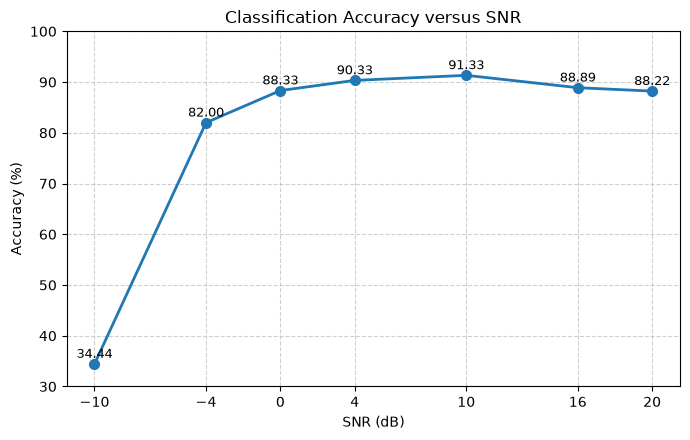

In [3]:
import matplotlib.pyplot as plt

# Experimental results
snr_db = [-10, -4, 0, 4, 10, 16, 20]
accuracy_percent = [
    34.44,
    82.00,
    88.33,
    90.33,
    91.33,
    88.89,
    88.22
]

# Plot
plt.figure(figsize=(7, 4.5))

plt.plot(
    snr_db,
    accuracy_percent,
    marker='o',
    linewidth=2,
    markersize=7
)

# Display value above each point
for x, y in zip(snr_db, accuracy_percent):
    plt.text(x, y + 1.2, f"{y:.2f}", ha='center', fontsize=9)

plt.title("Classification Accuracy versus SNR")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.xticks(snr_db)
plt.yticks(range(30, 101, 10))
plt.ylim(30, 100)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("overall_accuracy_vs_snr.png", dpi=300)
plt.show()

In [5]:
plt.savefig(
    "results/figures/overall_accuracy_vs_snr.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>